# Meuse: does MAX's mean DI hide cancellation?

This focused simulation evaluates **only maximum-entropy sampling (MAX)** and **only the Density Index (DI)** for the Meuse population at sample sizes $n=5,10,20$. It is designed to test the precise claim that a near-zero mean DI can arise because negative and positive sample-level DI values cancel.

The important distinction is: a near-zero **signed mean** describes the design average, whereas a small **mean absolute DI** would indicate that individual samples themselves tend to have DI near zero. The notebook reports both, as well as sign frequencies, conditional magnitudes, quantiles, confidence intervals, and full distributions.

The simulation covers both equal-probability (EP) and unequal-probability (UP) settings, uses 2,000 Monte Carlo samples per setting and sample size, and uses the referee-requested n-medoids DI representative.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

from graphical_sampling.population import Population
from graphical_sampling.index import DensityDisparity

warnings.filterwarnings('ignore', category=UserWarning, module='rpy2')
sns.set_theme(style='whitegrid', context='notebook')

Error importing in API mode: ModuleNotFoundError("No module named '_rinterface_cffi_api'")


Trying to import in ABI mode.


## Configuration

In [2]:
SAMPLE_SIZES = [5, 10, 20]
M = 2_000
SEED = 20260903
INCLUSIONS = ['EP', 'UP']
DI_REPRESENTATIVE = 'nmedoids'
DI_N_JOBS = -1
ZERO_TOL = 1e-12

# Resolve paths whether the notebook is launched from the repository root
# or from simulations/jupyters.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = next(p for p in candidates if (p / 'graphical_sampling').is_dir())
DATA_FILE = REPO_ROOT / 'simulations/populations/real/meuse.csv'
OUTPUT_DIR = REPO_ROOT / 'simulations/results/meuse_MAX_DI_cancellation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Population:', DATA_FILE)
print('Output:', OUTPUT_DIR)
print(f'M={M:,}; sample sizes={SAMPLE_SIZES}; inclusions={INCLUSIONS}; DI={DI_REPRESENTATIVE}')

Population: /home/bardia/projects/graphical-sampling/simulations/populations/real/meuse.csv
Output: /home/bardia/projects/graphical-sampling/simulations/results/meuse_MAX_DI_cancellation
M=2,000; sample sizes=[5, 10, 20]; inclusions=['EP', 'UP']; DI=nmedoids


## Generate MAX samples and calculate DI

`sampling::UPmaxentropy` draws fixed-size maximum-entropy samples. R is seeded separately for each sample size, making the result reproducible. Equal inclusion probabilities are $n/N$; for unequal probabilities, copper is used as the size measure, matching the original notebook.

In [3]:
def capped_inclusion_probabilities(weights, n):
    w = np.asarray(weights, dtype=float)
    pik = n * w / w.sum()
    while np.any(pik > 1):
        fixed = pik >= 1
        pik[fixed] = 1.0
        free = ~fixed
        pik[free] = (n - fixed.sum()) * w[free] / w[free].sum()
    return pik

def maxentropy_samples(pik, m, seed):
    N = len(pik)
    n = int(round(pik.sum()))
    samples = np.empty((m, n), dtype=int)
    ro.r('suppressPackageStartupMessages(library(sampling))')
    ro.r['set.seed'](seed)
    with localconverter(ro.default_converter + numpy2ri.converter):
        ro.globalenv['pik_py'] = np.asarray(pik, dtype=float)
        for i in tqdm(range(m), desc=f'MAX, n={n}'):
            out = np.asarray(ro.r('sampling::UPmaxentropy(pik_py)')).ravel()
            # The R function normally returns a 0/1 membership vector.
            idx = np.flatnonzero(out > 0.5) if out.size == N else out.astype(int) - 1
            if len(idx) != n or len(np.unique(idx)) != n:
                raise ValueError(f'Invalid MAX sample in iteration {i}: expected {n} unique units.')
            samples[i] = idx
    return samples

meuse = pd.read_csv(DATA_FILE)
coords = meuse[['x', 'y']].to_numpy(float)
N = len(meuse)
raw_parts = []

for inclusion_index, inclusion in enumerate(INCLUSIONS):
    for n in SAMPLE_SIZES:
        if inclusion == 'EP':
            pik = np.full(N, n / N, dtype=float)
        elif inclusion == 'UP':
            pik = capped_inclusion_probabilities(meuse['copper'].to_numpy(float), n)
        else:
            raise ValueError("Each inclusion setting must be 'EP' or 'UP'.")

        samples = maxentropy_samples(pik, M, SEED + 10_000 * inclusion_index + n)
        pop = Population(coords=coords, inclusions=pik, variable=meuse['cadmium'].to_numpy(float))
        scorer = DensityDisparity(population=pop, representative=DI_REPRESENTATIVE, n_jobs=DI_N_JOBS)
        di = scorer.score(samples)
        raw_parts.append(pd.DataFrame({
            'inclusion': inclusion, 'n': n,
            'iteration': np.arange(1, M + 1), 'DI': di
        }))

raw = pd.concat(raw_parts, ignore_index=True)
raw_file = OUTPUT_DIR / f'meuse_MAX_DI_raw_M={M}_EP_UP_{DI_REPRESENTATIVE}.csv'
raw.to_csv(raw_file, index=False)
display(raw.head())
print('Saved:', raw_file)

MAX, n=5:   0%|          | 0/2000 [00:00<?, ?it/s]

MAX, n=10:   0%|          | 0/2000 [00:00<?, ?it/s]

MAX, n=20:   0%|          | 0/2000 [00:00<?, ?it/s]

MAX, n=5:   0%|          | 0/2000 [00:00<?, ?it/s]

MAX, n=10:   0%|          | 0/2000 [00:00<?, ?it/s]

MAX, n=20:   0%|          | 0/2000 [00:00<?, ?it/s]

,inclusion,n,iteration,DI
0,EP,5,1,-0.311074
1,EP,5,2,-0.737790
2,EP,5,3,0.074303
3,EP,5,4,-0.351044
4,EP,5,5,0.185997


Saved: /home/bardia/projects/graphical-sampling/simulations/results/meuse_MAX_DI_cancellation/meuse_MAX_DI_raw_M=2000_EP_UP_nmedoids.csv


## Cancellation diagnostics

The cancellation percentage is $100\{1-|\bar D|/\overline{|D|}\}$. It is near 100% when sizable positive and negative contributions almost completely offset, and near 0% when they reinforce one another. This is a descriptive diagnostic, not a performance score. The bootstrap confidence intervals quantify Monte Carlo uncertainty in the signed mean and mean absolute DI.

In [4]:
def bootstrap_ci(x, statistic, seed, B=5_000):
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    boot = np.empty(B)
    for b in range(B):
        boot[b] = statistic(rng.choice(x, size=len(x), replace=True))
    return np.quantile(boot, [0.025, 0.975])

rows = []
for (inclusion, n), group in raw.groupby(['inclusion', 'n'], sort=True):
    x = group['DI'].to_numpy()
    pos = x[x > ZERO_TOL]
    neg = x[x < -ZERO_TOL]
    mean_ci = bootstrap_ci(x, np.mean, SEED + 100 + n)
    mad_ci = bootstrap_ci(x, lambda z: np.mean(np.abs(z)), SEED + 200 + n)
    mean_abs = np.mean(np.abs(x))
    rows.append({
        'inclusion': inclusion, 'n': n, 'M': len(x), 'mean_DI': np.mean(x), 'sd_DI': np.std(x, ddof=1),
        'mean_DI_CI_low': mean_ci[0], 'mean_DI_CI_high': mean_ci[1],
        'mean_abs_DI': mean_abs, 'mean_abs_DI_CI_low': mad_ci[0], 'mean_abs_DI_CI_high': mad_ci[1],
        'median_DI': np.median(x), 'median_abs_DI': np.median(np.abs(x)),
        'q05': np.quantile(x, .05), 'q25': np.quantile(x, .25),
        'q75': np.quantile(x, .75), 'q95': np.quantile(x, .95),
        'negative_pct': 100 * len(neg) / len(x),
        'near_zero_pct': 100 * np.mean(np.abs(x) <= ZERO_TOL),
        'positive_pct': 100 * len(pos) / len(x),
        'mean_negative_DI': np.mean(neg) if len(neg) else np.nan,
        'mean_positive_DI': np.mean(pos) if len(pos) else np.nan,
        'cancellation_pct': 100 * (1 - abs(np.mean(x)) / mean_abs) if mean_abs else 0.0,
        'abs_to_signed_ratio': mean_abs / max(abs(np.mean(x)), np.finfo(float).eps),
    })

summary = pd.DataFrame(rows)
summary_file = OUTPUT_DIR / f'meuse_MAX_DI_cancellation_summary_M={M}_EP_UP_{DI_REPRESENTATIVE}.csv'
summary.to_csv(summary_file, index=False)
display(summary.round(4))
print('Saved:', summary_file)

,inclusion,n,M,mean_DI,sd_DI,mean_DI_CI_low,mean_DI_CI_high,mean_abs_DI,mean_abs_DI_CI_low,mean_abs_DI_CI_high,...,q25,q75,q95,negative_pct,near_zero_pct,positive_pct,mean_negative_DI,mean_positive_DI,cancellation_pct,abs_to_signed_ratio
0,EP,5,2000,-0.0724,0.3123,-0.0858,-0.0588,0.2697,0.2622,0.2771,...,-0.3010,0.1996,0.3432,53.10,0.0,46.90,-0.3221,0.2103,73.1601,3.7258
1,EP,10,2000,-0.0014,0.2262,-0.0112,0.0085,0.1910,0.1858,0.1963,...,-0.1603,0.1691,0.3082,45.35,0.0,54.65,-0.2121,0.1735,99.2773,138.3796
2,EP,20,2000,0.0076,0.1472,0.0011,0.0139,0.1258,0.1224,0.1292,...,-0.0981,0.1188,0.2183,43.70,0.0,56.30,-0.1352,0.1185,93.9207,16.4492
3,UP,5,2000,-0.0901,0.3386,-0.1048,-0.0759,0.3032,0.2955,0.3108,...,-0.3433,0.2241,0.3733,56.50,0.0,43.50,-0.3480,0.2450,70.3003,3.3670
4,UP,10,2000,-0.0283,0.2441,-0.0387,-0.0178,0.2115,0.2061,0.2169,...,-0.2110,0.1731,0.3174,50.50,0.0,49.50,-0.2374,0.1850,86.6048,7.4654
5,UP,20,2000,-0.0142,0.1667,-0.0212,-0.0069,0.1433,0.1396,0.1470,...,-0.1368,0.1179,0.2217,50.15,0.0,49.85,-0.1570,0.1296,90.1225,10.1240


Saved: /home/bardia/projects/graphical-sampling/simulations/results/meuse_MAX_DI_cancellation/meuse_MAX_DI_cancellation_summary_M=2000_EP_UP_nmedoids.csv


## EP and UP frequency distributions

The 2 × 3 histograms compare sample-level DI relative frequencies for EP (top row) and UP (bottom row), at $n=5,10,20$. The bar heights sum to one within each panel. All panels use the same bins and axes. The black vertical line marks zero; no mean is drawn.

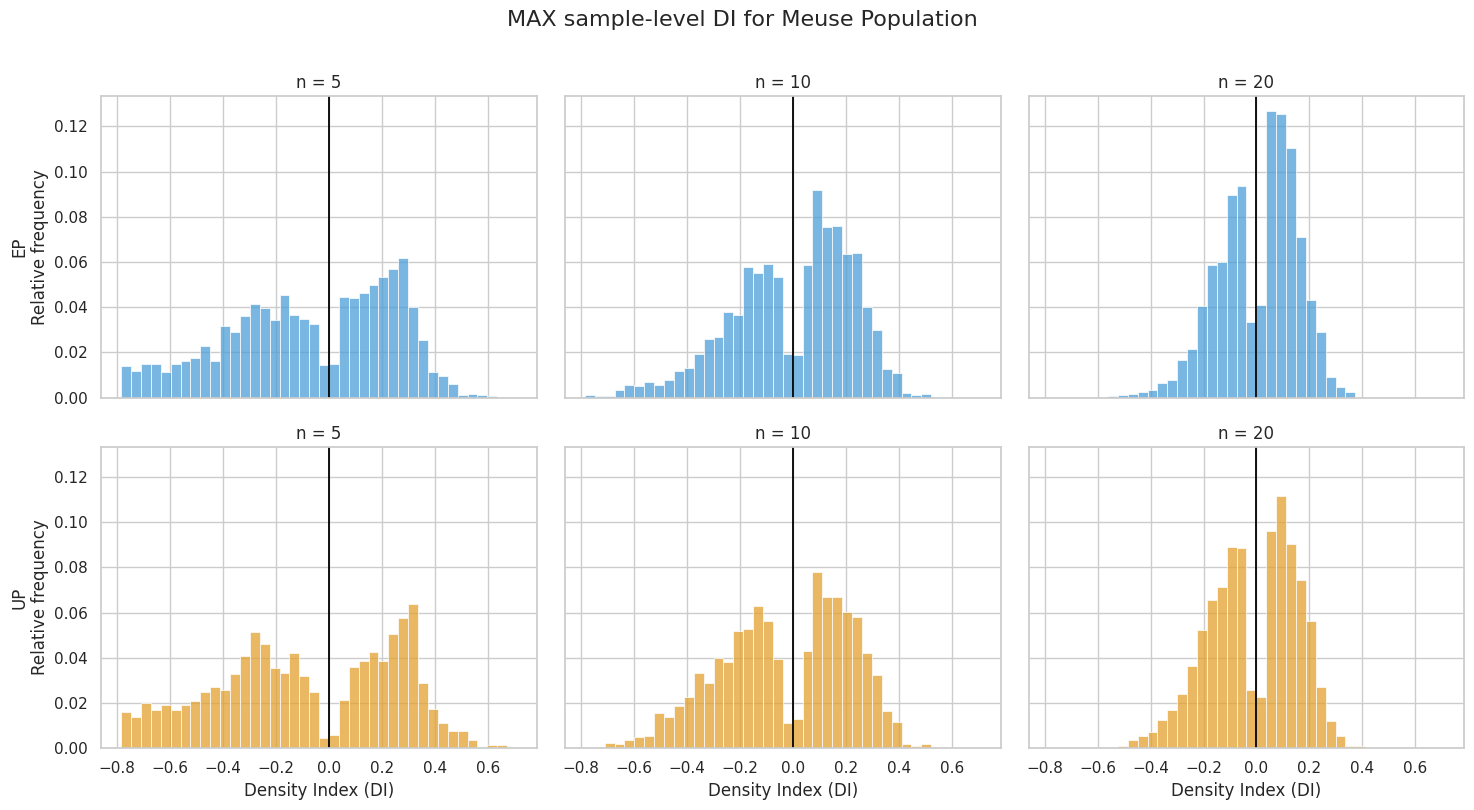

Saved: /home/bardia/projects/graphical-sampling/simulations/results/meuse_MAX_DI_cancellation/meuse_MAX_DI_frequencies_M=2000_EP_UP_nmedoids.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
row_colors = {'EP': '#4c9ed9', 'UP': '#e3a12f'}

# Use common bin edges so EP and UP frequencies are directly comparable.
bin_edges = np.linspace(raw['DI'].min(), raw['DI'].max(), 41)
for row, inclusion in enumerate(INCLUSIONS):
    for col, n in enumerate(SAMPLE_SIZES):
        ax = axes[row, col]
        x = raw.loc[(raw['inclusion'] == inclusion) & (raw['n'] == n), 'DI']
        sns.histplot(x=x, bins=bin_edges, stat='probability', color=row_colors[inclusion],
                     edgecolor='white', linewidth=0.5, ax=ax)
        ax.axvline(0, color='black', lw=1.3)
        ax.set_title(f'n = {n}')
        ax.set_xlabel('Density Index (DI)' if row == 1 else '')
        ax.set_ylabel(f'{inclusion}\nRelative frequency' if col == 0 else '')

fig.suptitle('MAX sample-level DI for Meuse Population', y=1.01, fontsize=16)
fig.tight_layout()
figure_file = OUTPUT_DIR / f'meuse_MAX_DI_frequencies_M={M}_EP_UP_{DI_REPRESENTATIVE}.png'
fig.savefig(figure_file, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', figure_file)

## Interpretation guide for the paper

Do **not** infer that MAX produces well-spread samples merely because `mean_DI` is close to zero. Use the diagnostics as follows:

- Evidence of cancellation: `mean_abs_DI` is materially larger than `abs(mean_DI)`, cancellation is high, and the histogram contains substantial mass on both sides of zero.
- Evidence against meaningful cancellation: the distribution is tightly concentrated near zero and `mean_abs_DI` is also small.
- A fair conclusion if cancellation is present is that this is a property of the **signed DI summary**, not automatically a drawback of MAX. Whether MAX itself is undesirable depends on the study objective and should be evaluated with dispersion/variability and application-level performance, not the signed mean alone.
- Under equal inclusion probabilities, fixed-size maximum-entropy sampling gives equal probability to all samples of size $n$ (the simple-random-sampling design). Thus MAX is not designed to enforce spatial spreading in this setting. Mixed sample configurations are expected from its entropy objective; they are not an implementation failure. However, lack of guaranteed spatial spreading can still be stated as a limitation when spatial balance is the design objective.

A manuscript-ready statement should be based on the computed values above. For example: *Although MAX's mean DI was close to zero, its mean absolute DI was [value], with [x]% negative and [y]% positive values. Thus, the near-zero mean reflects offsetting sample-level configurations rather than uniformly near-zero DI. This illustrates a limitation of interpreting the signed mean DI in isolation; it does not by itself establish a general drawback of the MAX design.*